In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./train_var_1.csv')
df

,Vmag,Plx,e_Plx,B-V,SpType,Amag,TargetClass
0,6.901420,24.569658,0.862829,0.737416,G5V,20.449126,1
1,4.334196,2.198947,0.593309,1.153210,G2Ib,13.043324,0
2,7.873019,11.750465,0.616568,0.589166,F5V,17.736492,1
3,8.110014,2.143815,0.848508,1.322107,K2III,15.592469,0
4,8.025193,4.165622,0.899296,1.141646,K5III,16.379680,0
...,...,...,...,...,...,...,...
31636,7.561113,0.692340,0.843319,0.252874,A0II,12.542120,0
31637,8.078011,3.002784,0.689891,0.971966,G8III,15.379710,0
31638,7.065964,7.820498,0.885794,0.435381,F3IV/V,16.737442,1
31639,8.685452,2.643033,1.064647,0.988600,K0III,14.859882,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31641 entries, 0 to 31640
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Vmag         31641 non-null  float64
 1   Plx          31641 non-null  float64
 2   e_Plx        31641 non-null  float64
 3   B-V          31641 non-null  float64
 4   SpType       31641 non-null  object 
 5   Amag         31641 non-null  float64
 6   TargetClass  31641 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 1.7+ MB


Датасет не имеет пустых значений

In [4]:
df.describe()

,Vmag,Plx,e_Plx,B-V,Amag,TargetClass
count,31641.000000,31641.000000,31641.000000,31641.000000,31641.000000,31641.000000
mean,7.657008,6.060009,1.030286,0.712615,16.053552,0.499321
std,1.743426,6.336226,0.348017,0.474148,2.349601,0.500007
min,-0.960192,-24.900856,0.336300,-0.409355,4.157485,0.000000
25%,7.181646,2.184676,0.809005,0.342697,14.749502,0.000000
50%,8.108187,4.047433,0.992616,0.712378,16.130040,0.000000
75%,8.772251,7.948651,1.195221,1.090438,17.486865,1.000000
max,12.537229,86.048127,5.805426,2.866545,27.222762,1.000000


Выглядит как нормальное распределение

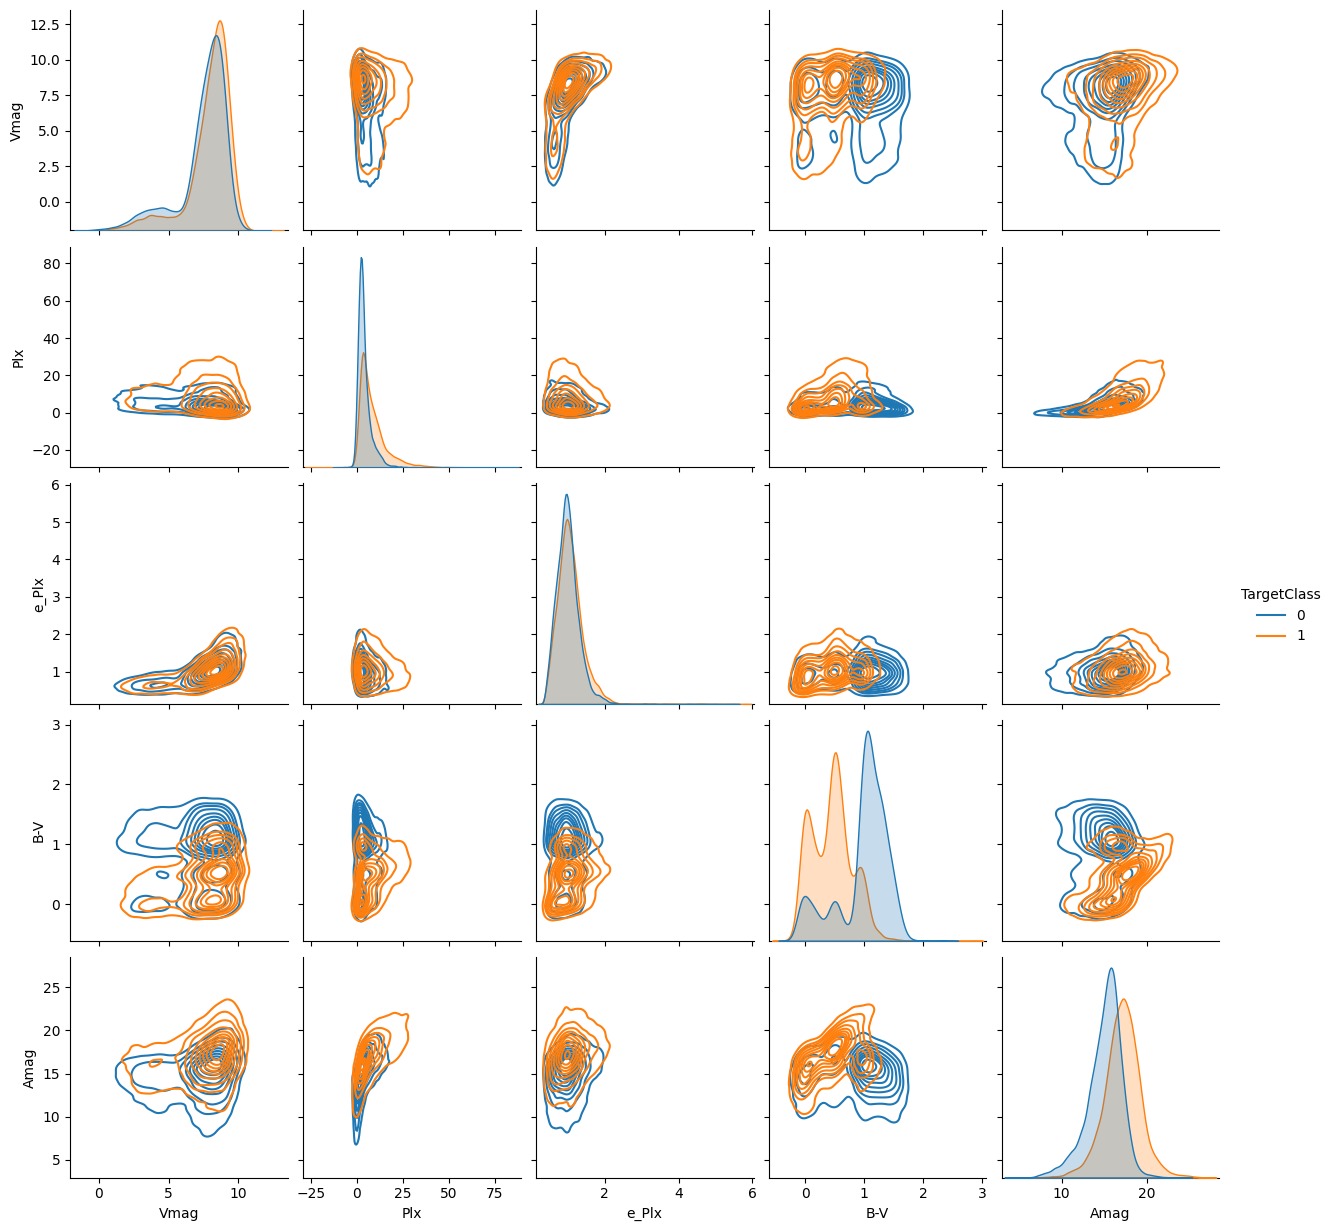

In [ ]:
sns.pairplot(df, hue='TargetClass', kind="kde", alpha=0.5)

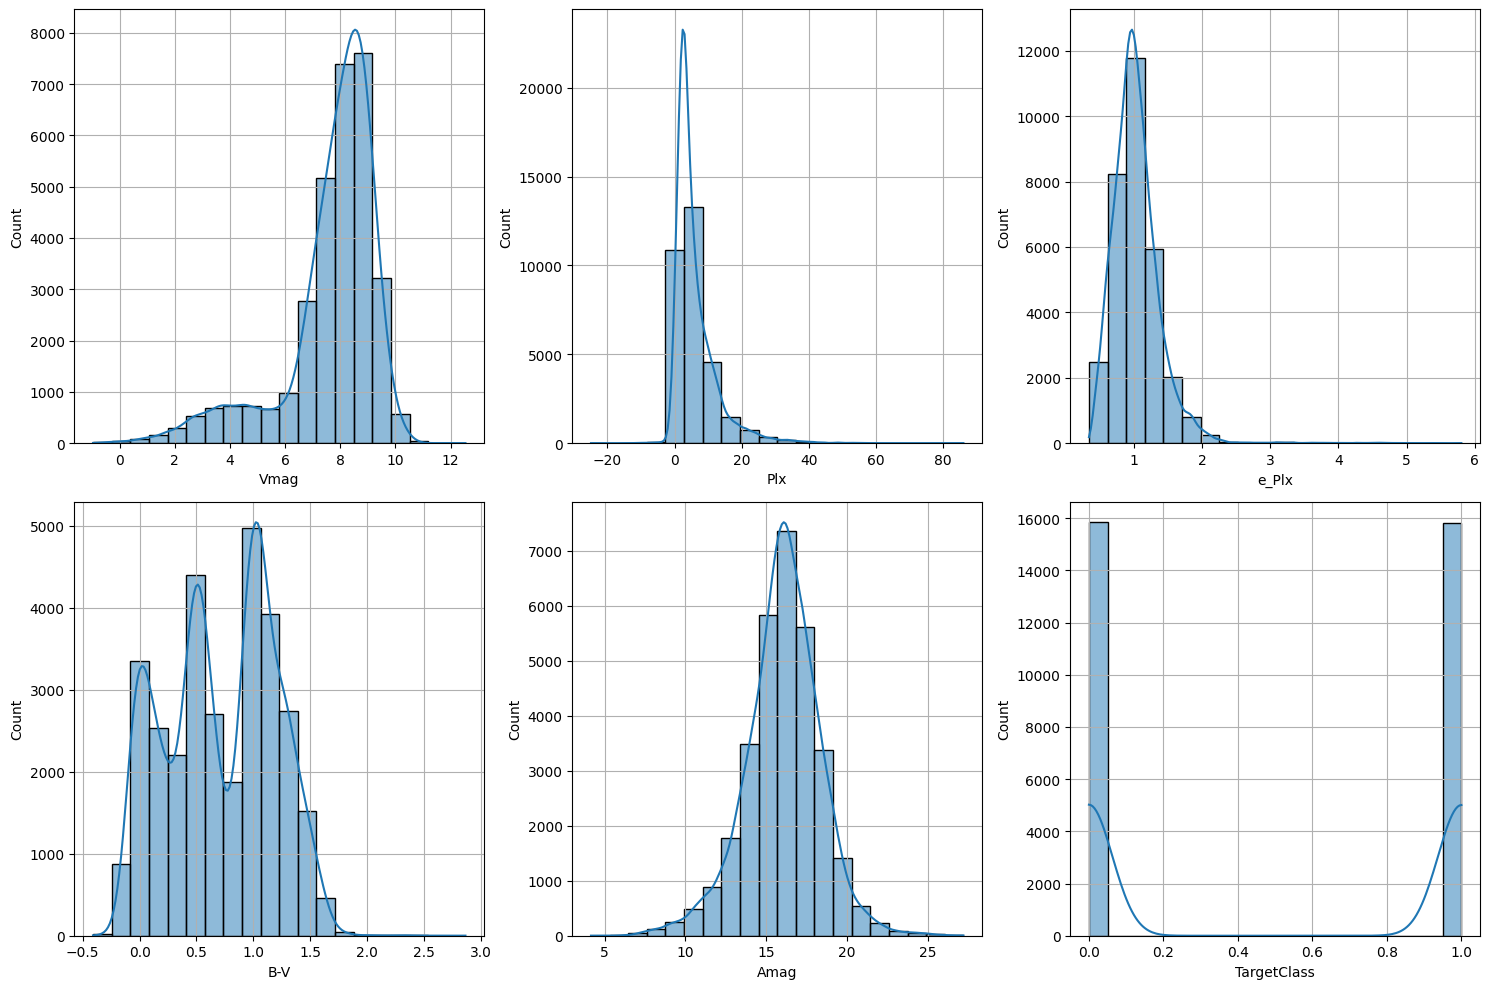

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
for i, col in enumerate(numeric_cols):
    ax = axes[i//3, i%3]
    sns.histplot(data=df, x=col, kde=True, bins=20, ax=ax)
    ax.grid(True)
plt.tight_layout()


(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0, 0.5, 'Vmag'),
  Text(0, 1.5, 'Plx'),
  Text(0, 2.5, 'e_Plx'),
  Text(0, 3.5, 'B-V'),
  Text(0, 4.5, 'Amag'),
  Text(0, 5.5, 'TargetClass')])

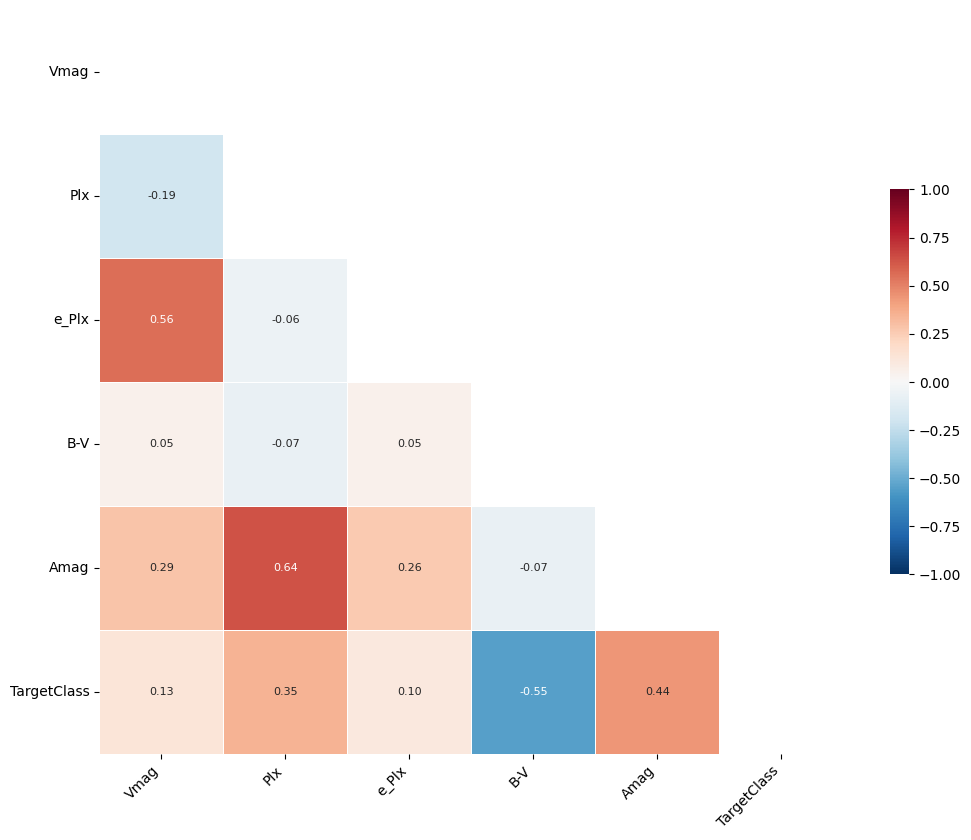

In [ ]:
# Compute the correlation matrix
corr = df.select_dtypes(include='number').corr()

# Generate a mask for the upper triangle 
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure with larger size for better visibility
plt.figure(figsize=(12, 10))

# Draw the heatmap with correlation values displayed
sns.heatmap(corr, 
            mask=mask,
            cmap="RdBu_r",
            vmin=-1, vmax=1,  # Set fixed scale for correlations
            center=0,
            square=True,
            linewidths=.5,
            annot=True,  # Show correlation values
            fmt='.2f',   # Format to 2 decimal places
            cbar_kws={"shrink": .5},
            annot_kws={"size": 8})  # Adjust annotation text size

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)


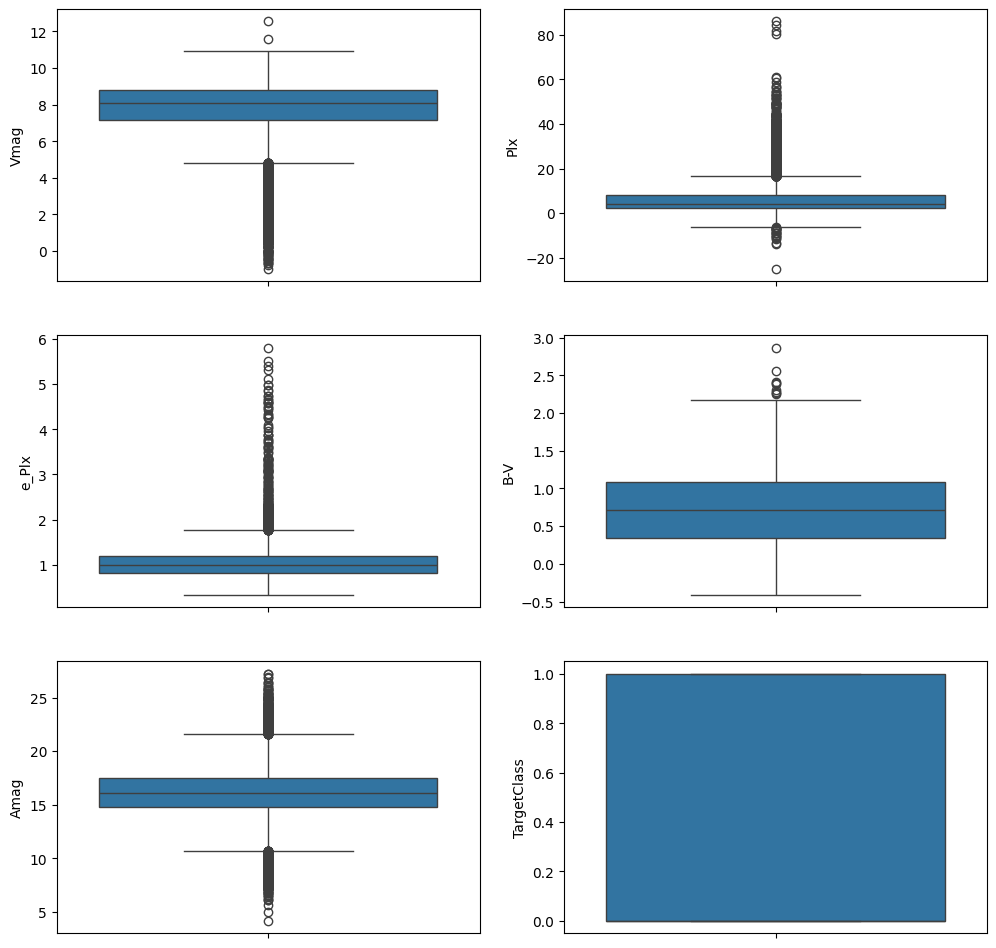

In [5]:
# Create boxplots to visualize the distribution of features across different target classes
fig, axes = plt.subplots(3, 2, figsize=(12,12))
for i, col in enumerate(['Vmag', 'Plx', 'e_Plx', 'B-V', 'Amag', 'TargetClass']):
    # Create boxplot showing distribution of each feature by target class
    sns.boxplot(data=df, y=col, ax=axes[i//2, i%2])
